In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
print(os.getcwd())

sns.set_theme(font_scale=0.7, style="white")

from itertools import groupby

sys.path.append("..")
from src.features import compute_chromagram
from src.visualization import plot_chromagram, plot_chord_similarity
from src.templates import generate_chord_templates, get_chord_labels, VOCAB_CLASSICAL, REFERENCE_ROOT_AB, REFERENCE_ROOT_C
from src.recognition import recognize_template

/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks


In [2]:
audio_path = "../data/audio/chopin_etude_op25_no01_snippet.m4a"

# Match the FMP reference: scale n_fft while keeping hop_length fixed.
# At sample_rate=22050, these are roughly 93 ms / 372 ms / 1486 ms windows.
variant = "IIR"
sample_rate = 22050
hop_length = 1024
n_fft_values = [2048, 8192, 32768]

for n_fft in n_fft_values:
    print(f"n_fft={n_fft:>5d}  window={n_fft / sample_rate * 1000:7.1f} ms")

n_fft= 2048  window=   92.9 ms
n_fft= 8192  window=  371.5 ms
n_fft=32768  window= 1486.1 ms


In [3]:
results = {}
for n_fft in n_fft_values:
    chroma = compute_chromagram(
        audio_path=audio_path,
        variant=variant,
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
    )
    recog = recognize_template(
        chroma=chroma,
        use_flats=True,
        vocab=VOCAB_CLASSICAL,
        reference_root=REFERENCE_ROOT_C,
    )
    results[n_fft] = (chroma, recog)

/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks/../src/features.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sample_rate = librosa.load(audio_path, sr=sample_rate)
/opt/homebrew/Caskroom/miniforge/base/envs/fmp_chord_recognition_env/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/Users/hannaharjonillo/Documents/Projects/fmp-chord-recognition/notebooks/../src/features.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sample_rate = librosa.load(audio_path, sr=sample_rate)
/opt/homebrew/Caskroom/miniforge/base/envs/fmp_chord_recognition_env/lib/python3.14/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in 

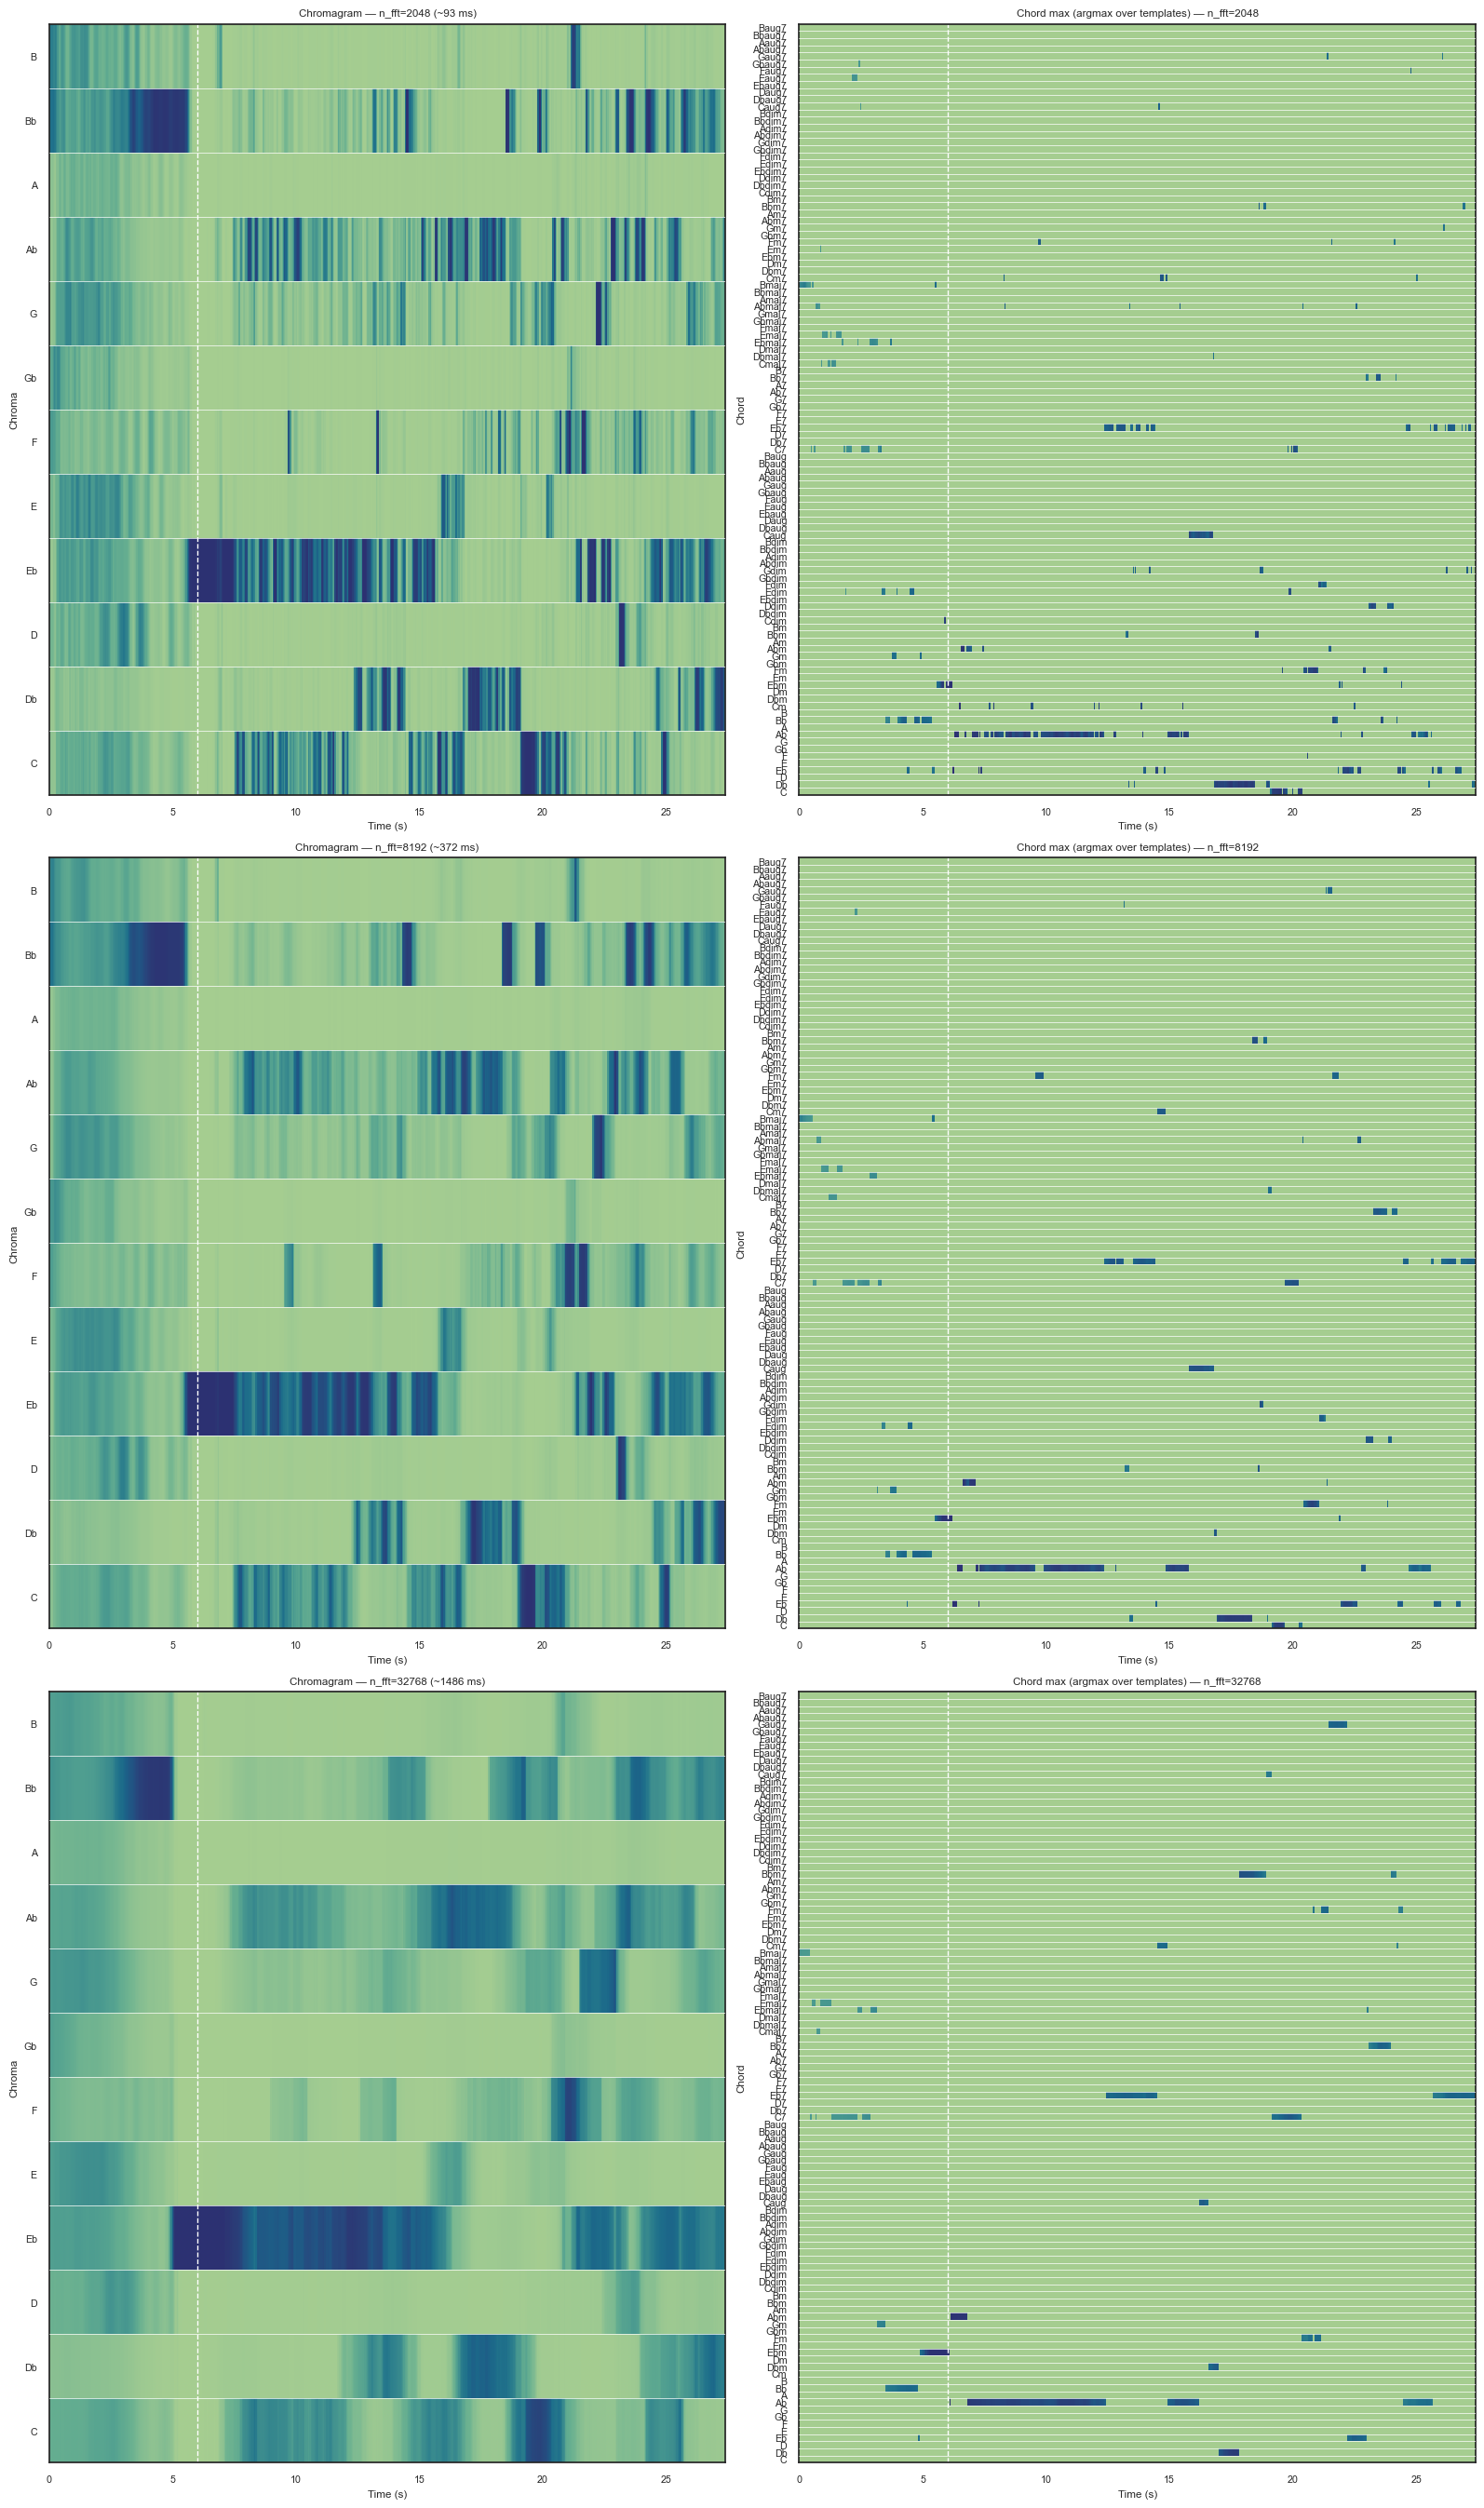

In [8]:
fig, axs = plt.subplots(len(n_fft_values), 2, figsize=(16, 9 * len(n_fft_values)),
                        gridspec_kw={"width_ratios": [1, 1]})
for i, n_fft in enumerate(n_fft_values):
    chroma, recog = results[n_fft]
    window_ms = n_fft / sample_rate * 1000
    plot_chromagram(
        X=chroma.X,
        feature_rate=chroma.feature_rate,
        ax=axs[i, 0],
        use_flats=True,
        reference_root=REFERENCE_ROOT_C,
        title=f"Chromagram — n_fft={n_fft} (~{window_ms:.0f} ms)",
    )
    axs[i, 0].axvline(6, color="white", linestyle="--", linewidth=1, label="Annotation start")
    plot_chord_similarity(
        chord_sim=recog.chord_max,
        feature_rate=chroma.feature_rate,
        ax=axs[i, 1],
        use_flats=True,
        title=f"Chord max (argmax over templates) — n_fft={n_fft}",
    )
    axs[i, 1].axvline(6, color="white", linestyle="--", linewidth=1, label="Annotation start")
fig.tight_layout()

In [5]:
# show chord progression starting at the 6s mark (actual piano start after some noise)
# TODO: filter that noise part out in the future. I can clean that up manually like I did for the snippet, 
# but would be nice to see it here as a reminder that it should be dealt with, ideally algorithmically,
# like with some sort of signal-to-noise ratio thresholding.

actual_start_seconds = 6
for n_fft in n_fft_values:
    chroma, recog = results[n_fft]
    start = int(actual_start_seconds * chroma.feature_rate)
    progression = [recog.labels[i] for i, _ in groupby(recog.chord_indices[start:])]
    print(f"\nn_fft={n_fft}  ({len(progression)} segments)")
    print(progression)



n_fft=2048  (128 segments)
['Ebm', 'Eb', 'Ab', 'Cm', 'Abm', 'Ab', 'Abm', 'Ab', 'Eb', 'Ab', 'Eb', 'Abm', 'Ab', 'Cm', 'Ab', 'Cm', 'Ab', 'Cm7', 'Abmaj7', 'Ab', 'Cm', 'Ab', 'Fm7', 'Ab', 'Cm', 'Ab', 'Cm', 'Ab', 'Eb7', 'Ab', 'Eb7', 'Bbm', 'Db', 'Abmaj7', 'Eb7', 'Gdim', 'Db', 'Gdim', 'Eb7', 'Cm', 'Ab', 'Eb', 'Eb7', 'Gdim', 'Eb7', 'Eb', 'Caug7', 'Cm7', 'Eb', 'Cm7', 'Ab', 'Abmaj7', 'Ab', 'Cm', 'Ab', 'Caug', 'Dbmaj7', 'Db', 'Bbm', 'Bbm7', 'Gdim', 'Bbm7', 'Db', 'C', 'Fm', 'C', 'C7', 'Edim', 'C7', 'C', 'C7', 'C', 'Abmaj7', 'Fm', 'F', 'Fm', 'Fdim', 'Gaug7', 'Abm', 'Fm7', 'Bb', 'Eb', 'Ebm', 'Ab', 'Ebm', 'Eb', 'Cm', 'Abmaj7', 'Eb', 'Ab', 'Fm', 'Bb7', 'Ddim', 'Bb7', 'Bb', 'Fm', 'Ddim', 'Fm7', 'Bb7', 'Bb', 'Eb', 'Ebm', 'Eb', 'Eb7', 'Faug7', 'Ab', 'Cm7', 'Ab', 'Db', 'Eb7', 'Ab', 'Eb', 'Eb7', 'Eb', 'Gaug7', 'Gm7', 'Eb7', 'Gdim', 'Eb7', 'Eb', 'Eb7', 'Bbm7', 'Eb7', 'Gdim', 'Eb7', 'Gdim', 'Db', 'Bbm7']

n_fft=8192  (55 segments)
['Ebm', 'Eb', 'Ab', 'Abm', 'Ab', 'Eb', 'Ab', 'Fm7', 'Ab', 'Eb7', 'Ab', 'Eb7', 

In [6]:
# load my own annotations on the piece
annot_chord_progression = pd.read_csv("../data/annotations/chopin_etude_op25_no01_snippet.csv")
annot_chord_progression

,measure,beat,chord
0,1,1,Ab:maj
1,1,2,Ab:maj
2,1,3,Ab:maj
3,1,4,Ab:maj
4,2,1,Ab:maj
5,2,2,Ab:maj
6,2,3,Ab:maj
7,2,4,Ab:maj
8,3,1,Eb:maj7
9,3,2,Eb:maj7


Notes on actual evaluation, which I still have to think/read about:
1. The first note is a single E-flat from the melodic line, so the similarities are likely distributed across multiple chords, and the first predicted chord of Ebm is understandable, but wrong. But also it's hard to tell without the next measure.
2. Dealing with arpeggios:
    1. problems:
        1. misclassified arpeggiated chords. It would also be interesting to see how much of the errors correlate with pedaling. So maybe I'll add that to my annotation, based on the recording if possible and not on the sheet
        2. temporal alignment between the annotations to the predictions. Or I can find a different way of annotating to "sync" it to the same audio file. double check what the usual standards are here
    1. solutions to 1:
        1. easier: modify window size manually, but determine appropriate window size
        2. more difficult: Beat tracking to compute the appropriate window size

Other to-do's:
- improve chord similarity plot for the expanded vocabulary